In [46]:
import pandas as pd
plate_name_to_inducer_dict = {
    'Plate 1': 'g-butyrolactam',
    'Plate 2': 'L-pyroglutamate',
    'Plate 3': 'g-valerolactone',
    'Plate 4': 'd-valerolactam',
    'Plate 5': 'ethyl-valerolactam',
    'Plate 6': 'd-valerolactone',
    'Plate 7': 'd-hexalactone',
    'Plate 8': 'cyclohexanone',
    'Plate 9': 'e-caprolactam',
    'Plate 10': 'e-caprolactone',
    'Plate 11': 'd-nonalactone',
    'Plate 12': 'no inducer'
}
well_to_mutant_df = pd.read_excel('notebooks/jacob/oplr_r2/2025.07.16 oplR characterization.xlsx')
well_to_mutant_df.head()

cyclohexanone_slate = '''E218L_Y255T
Y255L_A309P
Y255M_A309P
E218R_Y255L
K137P_Y255L
N139A_Y255L
E218T_Y255T
Y255M_Q296H
K144E_Y255L
E218R_Y255M
K144A_Y255T
Y255T_A309P
I252G_Y255M
K144E_Y255M
K144A_Y255L
K144D_Y255M
E218I_Y255T
E218M_Y255L
P29R_Y255L
E218R_Y255T
K144D_Y255L
Y255L_Q296H
K137A_Y255L
G237R_Y255T'''.split('\n')

ethyl_valerolactam_slate = '''W10V_Q123D
Q123D_V312Y
Q123D_Q155T
Q45R_Q123D
Q123D_A309P
D25R_Q63A
Q123D_L241I
Q63V_Q123D
Q12D_Q123D
Q123D_T190L
P2I_Q123D
Q16A_Q123D
Q63A_Q296H
Q123D_Q296H
Q99R_Q123D
Q123D_H318D
Q63A_E218I
Q45S_Q123D
Q123D_P254G
Q123D_A187I
Q123D_Q264K
Q123D_G237K
Q123D_Q155S
Q123D_Q303R'''.split('\n')

In [47]:
import numpy as np
import pandas as pd

big_df = pd.DataFrame()

for sheet_name_prefix in ['Plate 1', 'Plate 2', 'Plate 3', 'Plate 4', 'Plate 5', 'Plate 6', 'Plate 7', 'Plate 8', 'Plate 9', 'Plate 10', 'Plate 11', 'Plate 12']:
    sheet_name = f'{sheet_name_prefix} - Sheet1'
    table_df = pd.read_excel(
        'notebooks/jacob/oplr_r2/2025.07.18_FolDE_oplR_R2.xlsx', 
        sheet_name=sheet_name,
        skiprows=38,
        usecols='C:N'
    )

    od_df = table_df.iloc[0::3].copy()
    od_df.index = list('ABCDABCD')

    rfp_df = table_df.iloc[1::3].copy()
    rfp_df.index = list('ABCDABCD')

    didnt_grow = od_df < 0.1
    rfp_df[didnt_grow] = np.nan
    od_df[didnt_grow] = np.nan

    normed_rfp_df = rfp_df / od_df

    melted_od = od_df.reset_index(names='row').melt(id_vars='row', var_name='col', value_name='od')
    melted_rfp = rfp_df.reset_index(names='row').melt(id_vars='row', var_name='col', value_name='rfp')
    melted_normed_rfp_df = normed_rfp_df.reset_index(names='row').melt(id_vars='row', var_name='col', value_name='normed_rfp')

    melted_normed_rfp_df['plate_name'] = sheet_name_prefix
    big_df = pd.concat([big_df, melted_normed_rfp_df])

big_df['well'] = big_df['row'].astype(str) + big_df['col'].astype(str)

big_df = pd.merge(
    big_df,
    well_to_mutant_df[['Well', 'Mutant']],
    left_on='well',
    right_on='Well',
    how='inner'
)
big_df['inducer'] = big_df.plate_name.apply(lambda x: plate_name_to_inducer_dict[x])
big_df = big_df[['Mutant', 'inducer', 'normed_rfp']]

big_df.head()

,Mutant,inducer,normed_rfp
0,Q12D_Q123D,g-butyrolactam,1776.36153
1,Q123D_Q296H,g-butyrolactam,902.843602
2,Y146L_Y255T,g-butyrolactam,4.975124
3,Y255T_Q296C,g-butyrolactam,34.047919
4,Q12D_Q123D,g-butyrolactam,1781.553398


In [57]:
no_inducer_df = big_df[big_df.inducer == 'no inducer'].groupby('Mutant').normed_rfp.mean().reset_index().rename(columns={'normed_rfp': 'no_inducer_normed_rfp'})
final_df = big_df[big_df.inducer != 'no inducer']
final_df = pd.merge(
    final_df,
    no_inducer_df[['Mutant', 'no_inducer_normed_rfp']],
    left_on='Mutant',
    right_on='Mutant',
    how='left'
)
final_df['normed_normed_rfp'] = final_df.normed_rfp / final_df.no_inducer_normed_rfp
final_df = final_df[~final_df.Mutant.isna()]
# MUTANTS = ['WT'] + [v for v in final_df.Mutant.unique() if v != 'WT' and not (type(v) == float and np.isnan(v))]
def get_slate(mutant):
    if mutant == 'WT':
        return 'WT'
    if mutant in cyclohexanone_slate:
        return 'cyclohexanone slate'
    if mutant in ethyl_valerolactam_slate:
        return 'ethyl-valerolactam slate'
    return 'delta-nonalactone slate'
final_df['slate'] = final_df.Mutant.apply(get_slate)
final_df.head()

,Mutant,inducer,normed_rfp,no_inducer_normed_rfp,normed_normed_rfp,slate
0,Q12D_Q123D,g-butyrolactam,1776.36153,15.45105,114.967042,ethyl-valerolactam slate
1,Q123D_Q296H,g-butyrolactam,902.843602,10.924557,82.643498,ethyl-valerolactam slate
2,Y146L_Y255T,g-butyrolactam,4.975124,5.123398,0.97106,delta-nonalactone slate
3,Y255T_Q296C,g-butyrolactam,34.047919,3.832174,8.884753,delta-nonalactone slate
4,Q12D_Q123D,g-butyrolactam,1781.553398,15.45105,115.303063,ethyl-valerolactam slate


In [58]:
final_df.inducer.unique()

array(['g-butyrolactam', 'L-pyroglutamate', 'g-valerolactone',
       'd-valerolactam', 'ethyl-valerolactam', 'd-hexalactone',
       'cyclohexanone', 'e-caprolactam', 'e-caprolactone',
       'd-nonalactone'], dtype=object)

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_48028/570873034.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels(axs[-1].get_xticklabels(), rotation=90)


[Text(0, 0, 'WT'),
 Text(1, 0, 'Q123D_Q303R'),
 Text(2, 0, 'Q123D_G237K'),
 Text(3, 0, 'Q99R_Q123D'),
 Text(4, 0, 'Q123D_L241I'),
 Text(5, 0, 'Q123D_Q155S'),
 Text(6, 0, 'Q45S_Q123D'),
 Text(7, 0, 'Q123D_Q296H'),
 Text(8, 0, 'Q12D_Q123D'),
 Text(9, 0, 'Q123D_Q264K'),
 Text(10, 0, 'Q123D_A309P'),
 Text(11, 0, 'Q63A_E218I'),
 Text(12, 0, 'Q63V_Q123D'),
 Text(13, 0, 'Q45S_Q123D_A292D'),
 Text(14, 0, 'Y255T_Q296C'),
 Text(15, 0, 'Q123D_P254G'),
 Text(16, 0, 'Y255L_Q296H'),
 Text(17, 0, 'E218L_Y255T'),
 Text(18, 0, 'Q123D_Y255R'),
 Text(19, 0, 'Y255T_Q296H'),
 Text(20, 0, 'Y255M_A309P'),
 Text(21, 0, 'K144D_Y255L'),
 Text(22, 0, 'Q75R_Y255T'),
 Text(23, 0, 'Y146A_Y255T'),
 Text(24, 0, 'Y146I_Y255T'),
 Text(25, 0, 'Y146C_Y255T'),
 Text(26, 0, 'Y220H_Y255M'),
 Text(27, 0, 'K144A_Y255T'),
 Text(28, 0, 'xY146T_Y255T'),
 Text(29, 0, 'Y255L_A309P'),
 Text(30, 0, 'E218R_Y255T'),
 Text(31, 0, 'Y255T_Q296R'),
 Text(32, 0, 'Y146L_Y255T'),
 Text(33, 0, 'K144E_Y255L'),
 Text(34, 0, 'E218R_Y255M'),
 Tex

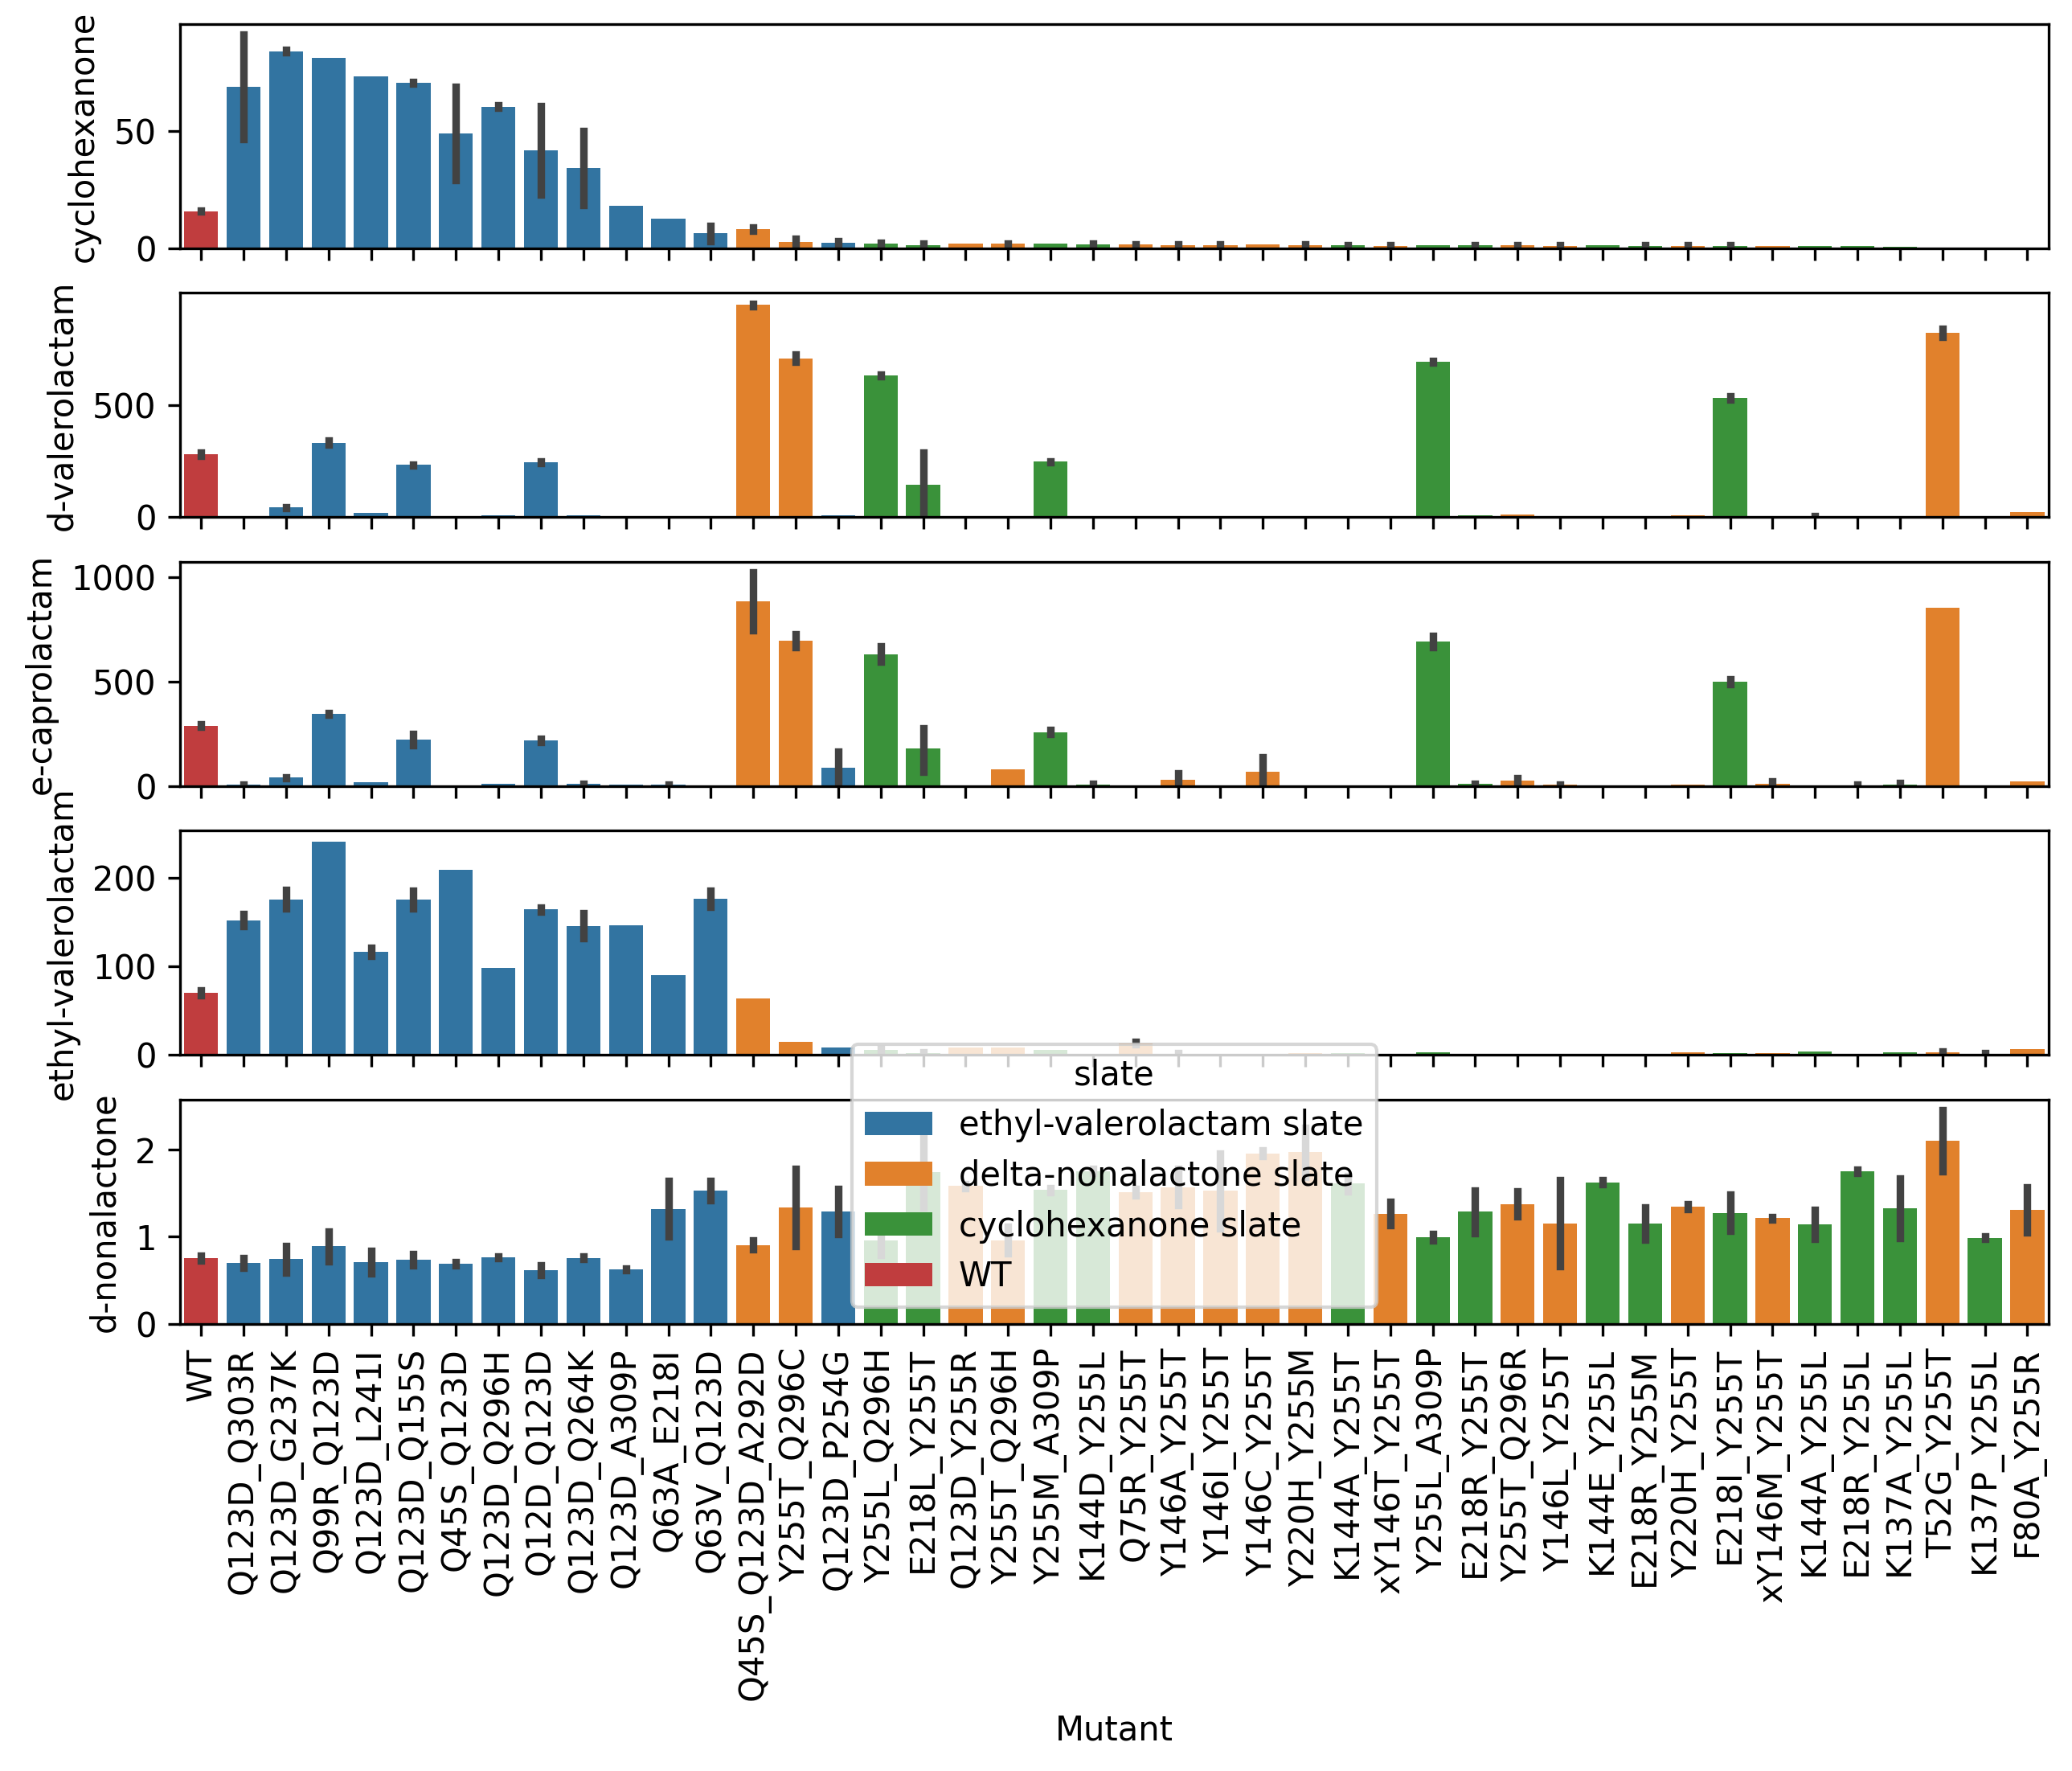

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

METABOLITES = [
    'cyclohexanone',
    'd-valerolactam',
    'e-caprolactam',
    'ethyl-valerolactam',
    'd-nonalactone'
]

fig, (axs) = plt.subplots(5, 1, figsize=(10, 7), dpi=300, sharex=True)

plot_df = final_df.copy()
MUTANTS = plot_df[plot_df.inducer == METABOLITES[0]].sort_values(by='normed_normed_rfp', ascending=False).Mutant.unique()

for metabolite, ax in zip(METABOLITES, axs):
    sns.barplot(
        data=final_df[final_df.inducer == metabolite],
        x='Mutant',
        y='normed_normed_rfp',
        ax=ax,
        order=['WT'] + [v for v in MUTANTS if v != 'WT'],
        hue='slate'
    )
    ax.set_ylabel(metabolite)
for ax in axs[:-1]:
    ax.legend_.remove()
axs[-1].set_xticklabels(axs[-1].get_xticklabels(), rotation=90)

In [60]:
final_df[final_df.Mutant.isna()]

,Mutant,inducer,normed_rfp,no_inducer_normed_rfp,normed_normed_rfp,slate


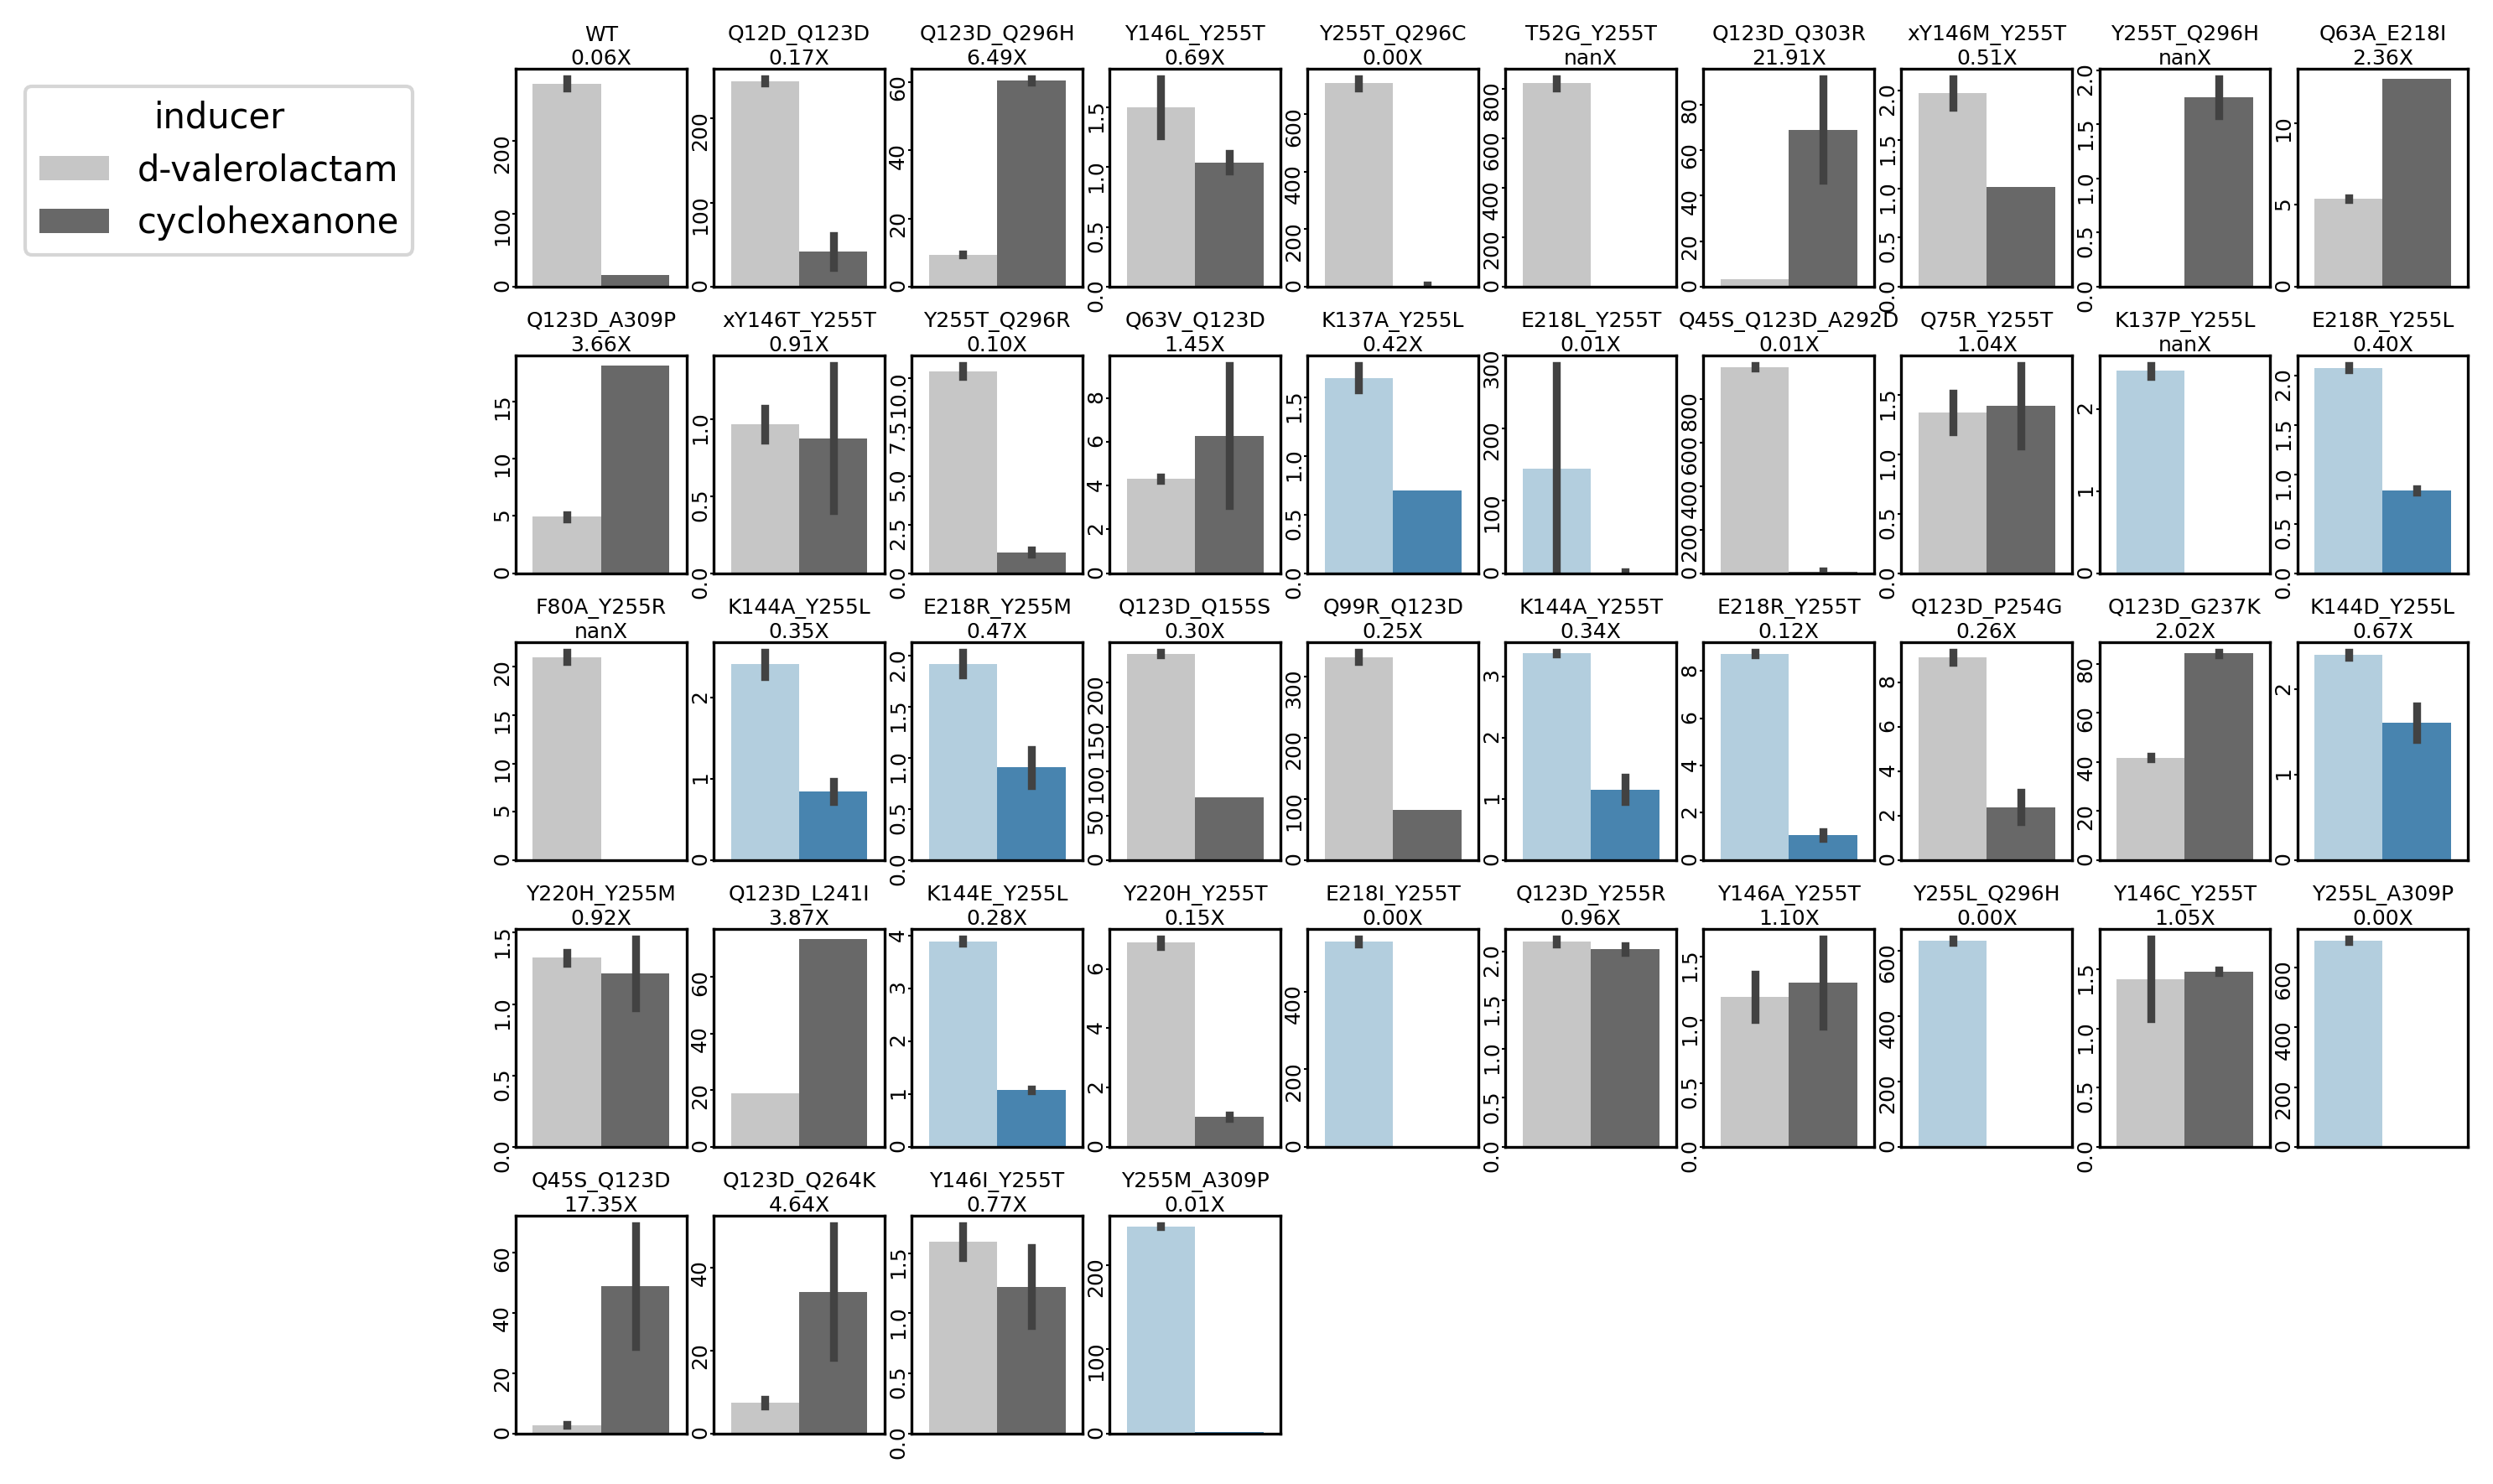

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

METABOLITE = 'cyclohexanone'

fig, axs = plt.subplots(5, 10, figsize=(10, 6), dpi=300, sharex=True)

mutant_idx = 0
METABOLITES = [
    'cyclohexanone',
    'd-valerolactam',
]
MUTANTS = ['WT'] + [v for v in final_df.Mutant.unique() if v != 'WT' and not (type(v) == float and np.isnan(v))]


for ax in axs.flatten():
    if mutant_idx >= len(MUTANTS):
        ax.remove()
        continue
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
    plot_df = final_df[final_df.inducer.isin(METABOLITES) & (final_df.Mutant == MUTANTS[mutant_idx])]
    cyclo_induction = plot_df[plot_df.inducer == 'cyclohexanone'].normed_normed_rfp.mean()
    val_induction = plot_df[plot_df.inducer == 'd-valerolactam'].normed_normed_rfp.mean()
    ratio = cyclo_induction / val_induction

    palette = 'Greys'
    if MUTANTS[mutant_idx] in cyclohexanone_slate:
        palette = 'Blues'

    sns.barplot(
        data=plot_df,
        # x='inducer',
        hue='inducer',
        y='normed_normed_rfp',
        ax=ax,
        palette=palette,
    )
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_title(MUTANTS[mutant_idx])
    ax.set_ylabel('')
    ax.set_title(f'{MUTANTS[mutant_idx]}\n{ratio:.2f}X', fontsize=6, pad=0)
    ax.tick_params(axis='y', labelsize=6, pad=0, length=1, width=0.5, rotation=90)  # Shrink y-tick marks and labels
    ax.tick_params(axis='x', length=0)

    mutant_idx += 1

for ii, ax_list in enumerate(axs):
    for jj, ax in enumerate(ax_list):
        if ii == 0 and jj == 0:
            continue
        if ax.legend_ is not None:
            ax.legend_.remove()
        # ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
# Get legend from first subplot and adjust position
legend = axs[0,0].get_legend()
legend.set_bbox_to_anchor((-0.5, 1))
fig.tight_layout(
    h_pad=0.0,  # vertical space between rows
    w_pad=0.1   # horizontal space between columns (reduce as needed)
)  # h_pad is in points, not relative units


# Let's redo it with scores!

In [63]:
final_df

,Mutant,inducer,normed_rfp,no_inducer_normed_rfp,normed_normed_rfp,slate
0,Q12D_Q123D,g-butyrolactam,1776.36153,15.45105,114.967042,ethyl-valerolactam slate
1,Q123D_Q296H,g-butyrolactam,902.843602,10.924557,82.643498,ethyl-valerolactam slate
2,Y146L_Y255T,g-butyrolactam,4.975124,5.123398,0.97106,delta-nonalactone slate
3,Y255T_Q296C,g-butyrolactam,34.047919,3.832174,8.884753,delta-nonalactone slate
4,Q12D_Q123D,g-butyrolactam,1781.553398,15.45105,115.303063,ethyl-valerolactam slate
...,...,...,...,...,...,...
915,WT,d-nonalactone,9.469697,12.084337,0.783634,WT
916,Q123D_Q264K,d-nonalactone,8.403361,11.284485,0.744683,ethyl-valerolactam slate
917,Y146I_Y255T,d-nonalactone,4.934211,4.496731,1.097288,delta-nonalactone slate
918,Y255M_A309P,d-nonalactone,6.722689,4.442715,1.513194,cyclohexanone slate


In [83]:
grouped_scores_df = final_df.groupby(['Mutant', 'inducer']).normed_normed_rfp.mean().reset_index()
pivoted_score_df = grouped_scores_df.pivot(index='Mutant', columns='inducer', values='normed_normed_rfp')

def get_cyclohexanone_score(row):
    specificity = row['cyclohexanone'] / (
        row['cyclohexanone'] + row['d-valerolactam'] + row['e-caprolactam'] + row['ethyl-valerolactam']
    )
    return np.log(row['cyclohexanone']) * specificity


def get_ethyl_valerolactam_score(row):
    specificity = row['ethyl-valerolactam'] / (
        row['d-valerolactam'] + row['e-caprolactam'] + row['ethyl-valerolactam']
    )
    return np.log(row['ethyl-valerolactam']) * specificity

pivoted_score_df['cyclohexanone_score'] = pivoted_score_df.apply(get_cyclohexanone_score, axis=1)
pivoted_score_df['ethyl_valerolactam_score'] = pivoted_score_df.apply(get_ethyl_valerolactam_score, axis=1)
pivoted_score_df['d_nonalactone_score'] = pivoted_score_df['d-nonalactone']

pivoted_score_df = pivoted_score_df[['cyclohexanone_score', 'ethyl_valerolactam_score', 'd_nonalactone_score']]
score_df = pivoted_score_df.reset_index().melt(id_vars='Mutant', var_name='inducer', value_name='score')
score_df['slate'] = score_df.Mutant.apply(get_slate)

wt_score_df = score_df[score_df.Mutant == 'WT']
score_df = pd.merge(
    score_df,
    wt_score_df[['inducer', 'score']].rename(columns={'score': 'wt_score'}),
    on='inducer',
    how='left'
)
score_df['score_ratio'] = score_df.score / score_df.wt_score

score_df.head()

,Mutant,inducer,score,slate,wt_score,score_ratio
0,E218I_Y255T,cyclohexanone_score,0.000005,cyclohexanone slate,0.066609,0.000072
1,E218L_Y255T,cyclohexanone_score,0.00104,cyclohexanone slate,0.066609,0.015619
2,E218R_Y255L,cyclohexanone_score,-0.018842,cyclohexanone slate,0.066609,-0.282878
3,E218R_Y255M,cyclohexanone_score,-0.014778,cyclohexanone slate,0.066609,-0.221862
4,E218R_Y255T,cyclohexanone_score,0.003249,cyclohexanone slate,0.066609,0.048777


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_48028/1272107806.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels(axs[-1].get_xticklabels(), rotation=90)


[Text(0, 0, 'WT'),
 Text(1, 0, 'Q123D_Q296H'),
 Text(2, 0, 'Q123D_L241I'),
 Text(3, 0, 'Q123D_Q303R'),
 Text(4, 0, 'Q123D_G237K'),
 Text(5, 0, 'Q45S_Q123D'),
 Text(6, 0, 'Q123D_Q264K'),
 Text(7, 0, 'Q123D_Q155S'),
 Text(8, 0, 'Q99R_Q123D'),
 Text(9, 0, 'Q123D_A309P'),
 Text(10, 0, 'Q63A_E218I'),
 Text(11, 0, 'Q12D_Q123D'),
 Text(12, 0, 'Q123D_Y255R'),
 Text(13, 0, 'K144D_Y255L'),
 Text(14, 0, 'Q63V_Q123D'),
 Text(15, 0, 'Y146I_Y255T'),
 Text(16, 0, 'Y220H_Y255M'),
 Text(17, 0, 'Q75R_Y255T'),
 Text(18, 0, 'Q123D_P254G'),
 Text(19, 0, 'K144A_Y255T'),
 Text(20, 0, 'Y146A_Y255T'),
 Text(21, 0, 'K144E_Y255L'),
 Text(22, 0, 'Q45S_Q123D_A292D'),
 Text(23, 0, 'Y146C_Y255T'),
 Text(24, 0, 'Y146L_Y255T'),
 Text(25, 0, 'E218R_Y255T'),
 Text(26, 0, 'Y255T_Q296R'),
 Text(27, 0, 'Y255M_A309P'),
 Text(28, 0, 'Y255T_Q296C'),
 Text(29, 0, 'Y220H_Y255T'),
 Text(30, 0, 'E218L_Y255T'),
 Text(31, 0, 'xY146M_Y255T'),
 Text(32, 0, 'Y255L_Q296H'),
 Text(33, 0, 'Y255L_A309P'),
 Text(34, 0, 'E218I_Y255T'),
 Tex

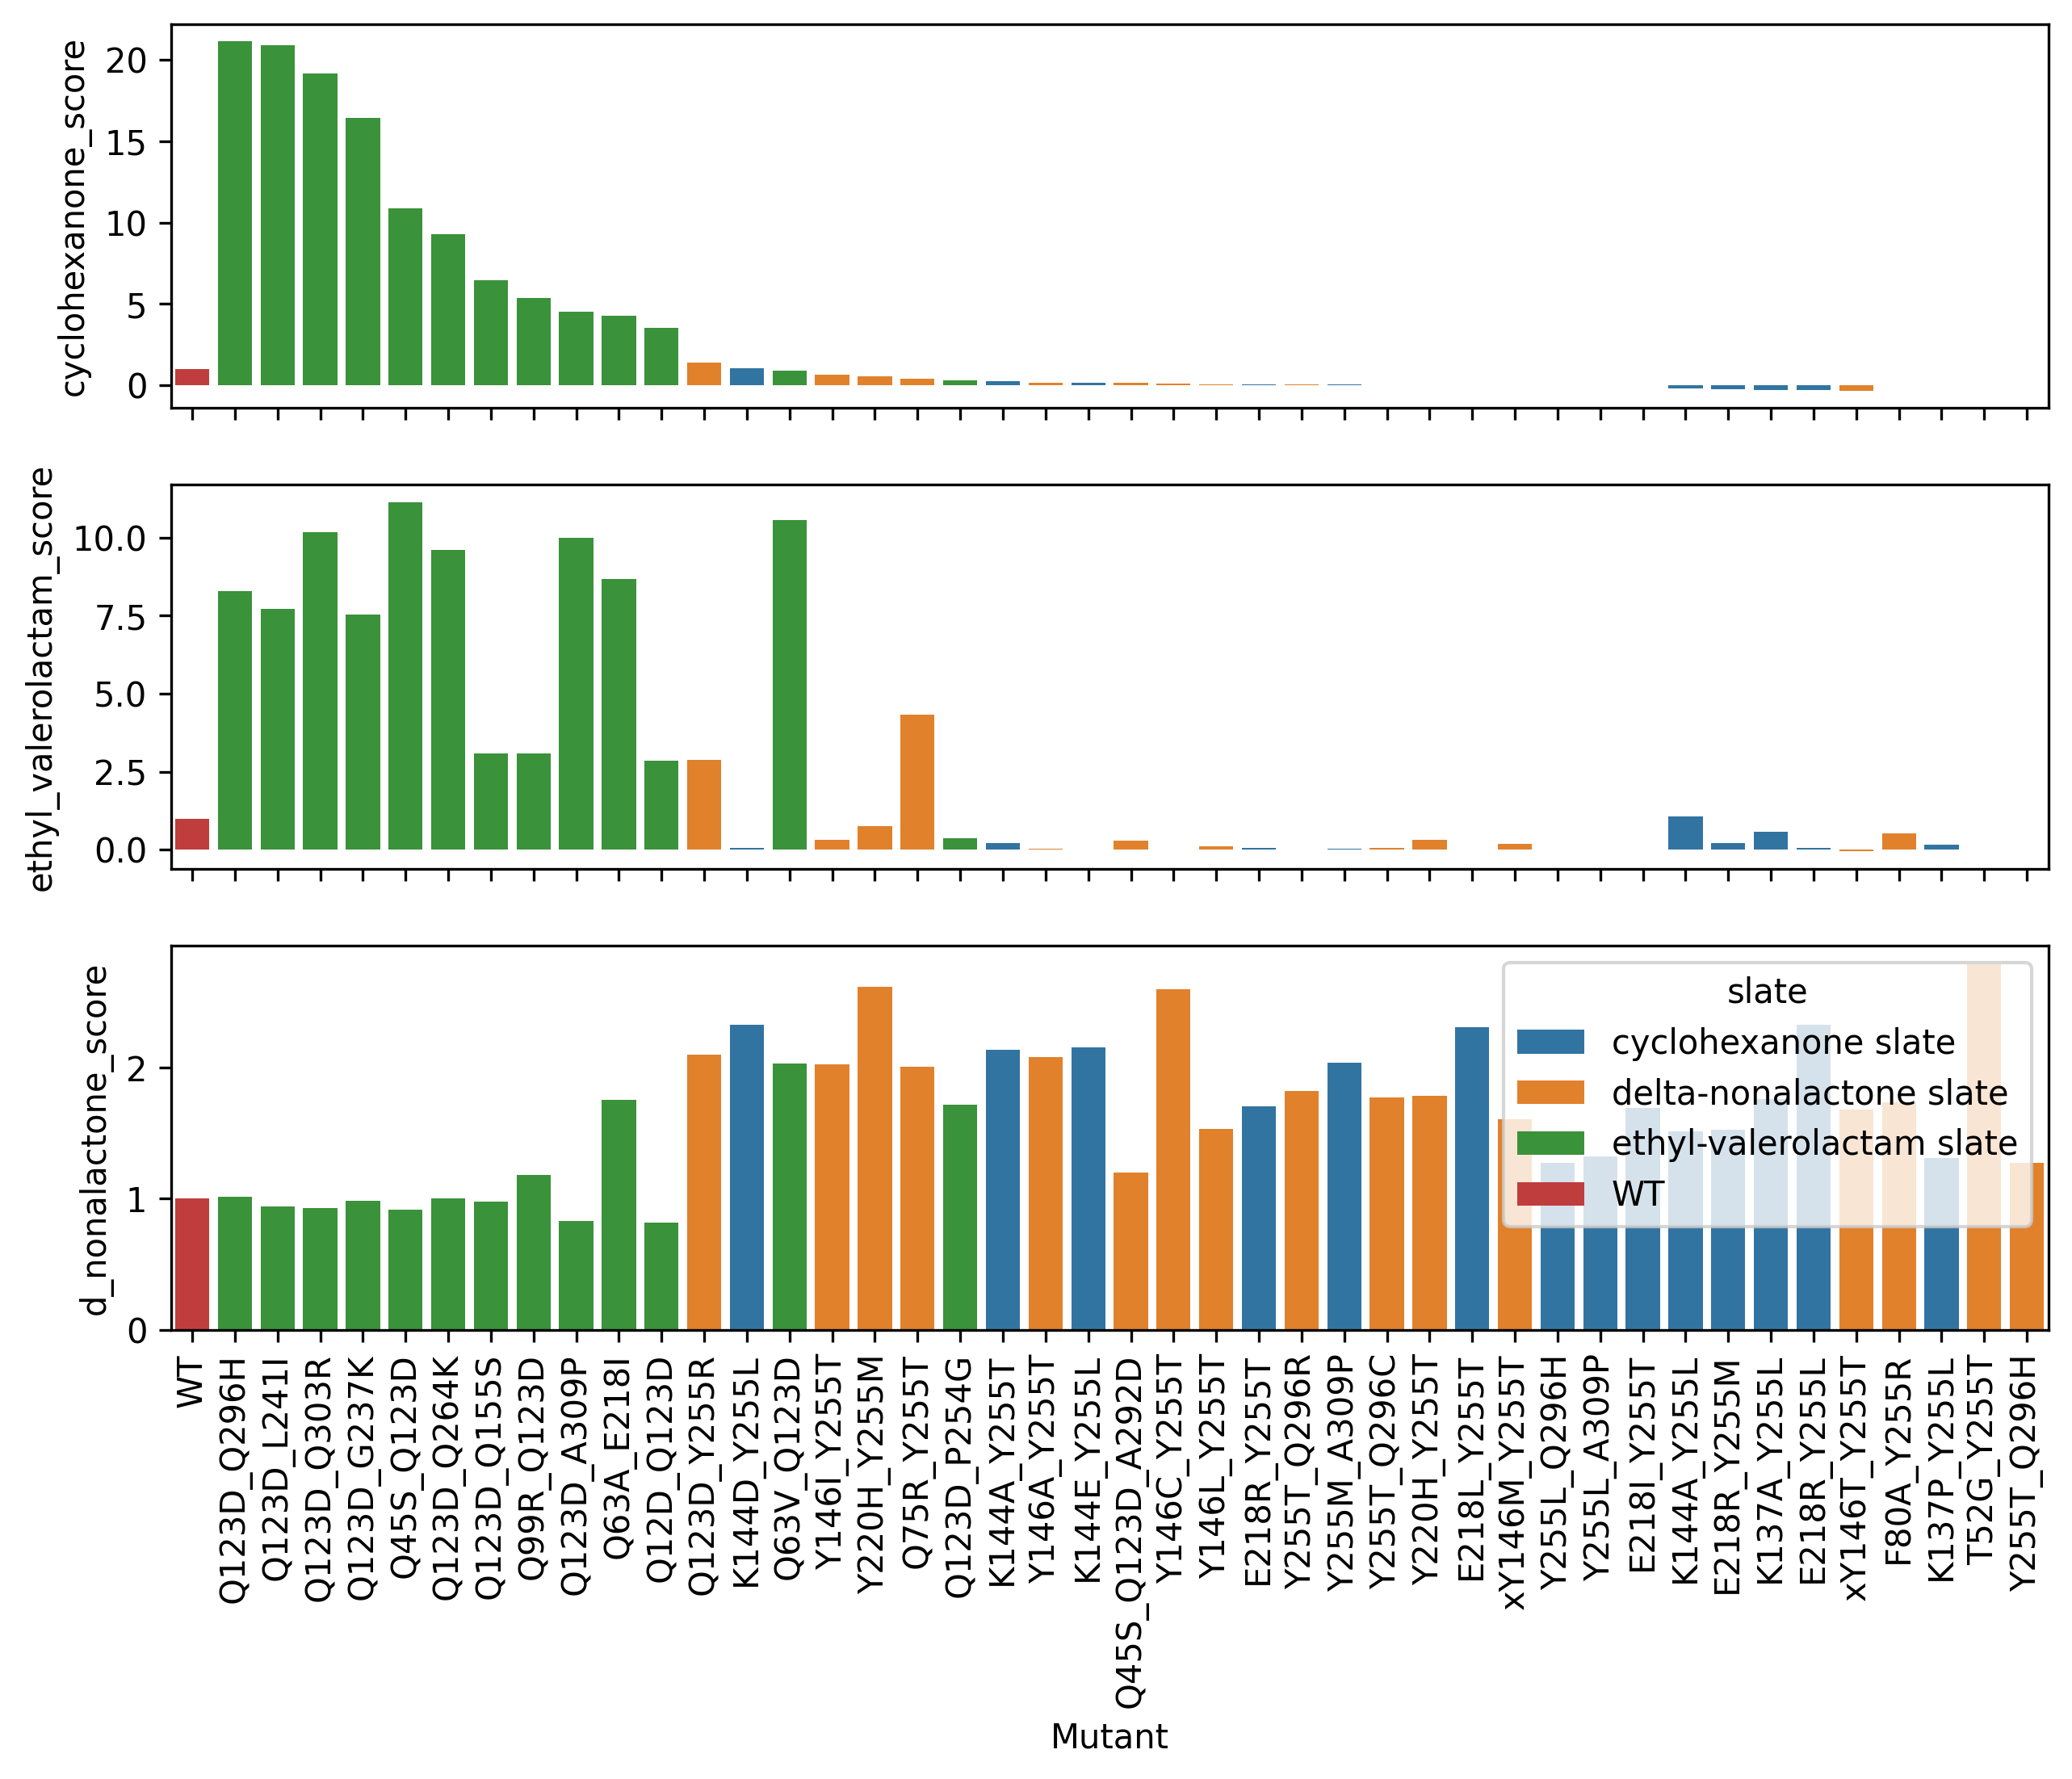

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

SCORES = [
    'cyclohexanone_score',
    'ethyl_valerolactam_score',
    'd_nonalactone_score'
]

fig, (axs) = plt.subplots(3, 1, figsize=(10, 7), dpi=300, sharex=True)

plot_df = final_df.copy()
MUTANTS = score_df[score_df.inducer == SCORES[0]].sort_values(by='score', ascending=False).Mutant.unique()

for score_name, ax in zip(SCORES, axs):
    sns.barplot(
        data=score_df[score_df.inducer == score_name],
        x='Mutant',
        y='score_ratio',
        ax=ax,
        order=['WT'] + [v for v in MUTANTS if v != 'WT'],
        hue='slate'
    )
    ax.set_ylabel(score_name)
for ax in axs[:-1]:
    ax.legend_.remove()
axs[-1].set_xticklabels(axs[-1].get_xticklabels(), rotation=90)